
  Validation  R²   : 0.9441
  Validation  MAE  : 0.3896
  Validation  RMSE : 0.8280

  Healthy error mean : 0.389590
  Healthy error std  : 0.417865
  ── Threshold set to : 1.643185  (mean + 3 × std) ──

  Feature importance:
    Reboiler_Spec         0.8303
    Condenser_Spec        0.1697

  Model saved to  models/


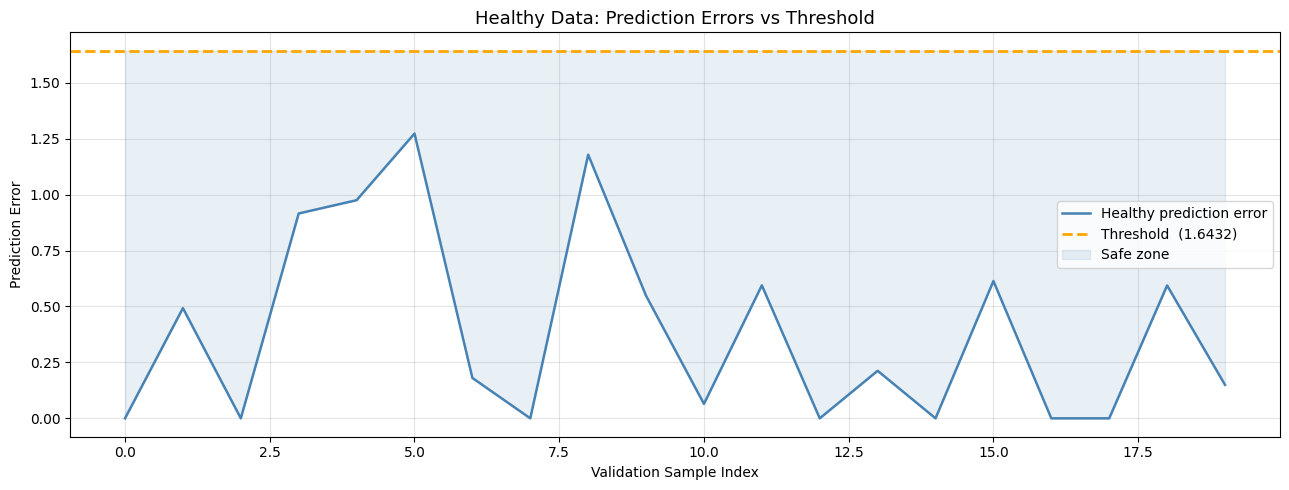


  Faulty data  R²   : -0.0918
  Faulty data  MAE  : 8.0928
  Faulty data  RMSE : 16.2584

  Total samples checked : 100
  Anomalies detected    : 89
  Fault percentage      : 89.0 %

  Early Warning System:
  ⚠️  EARLY WARNING at sample index : 7
      (5 consecutive anomalies starting there)


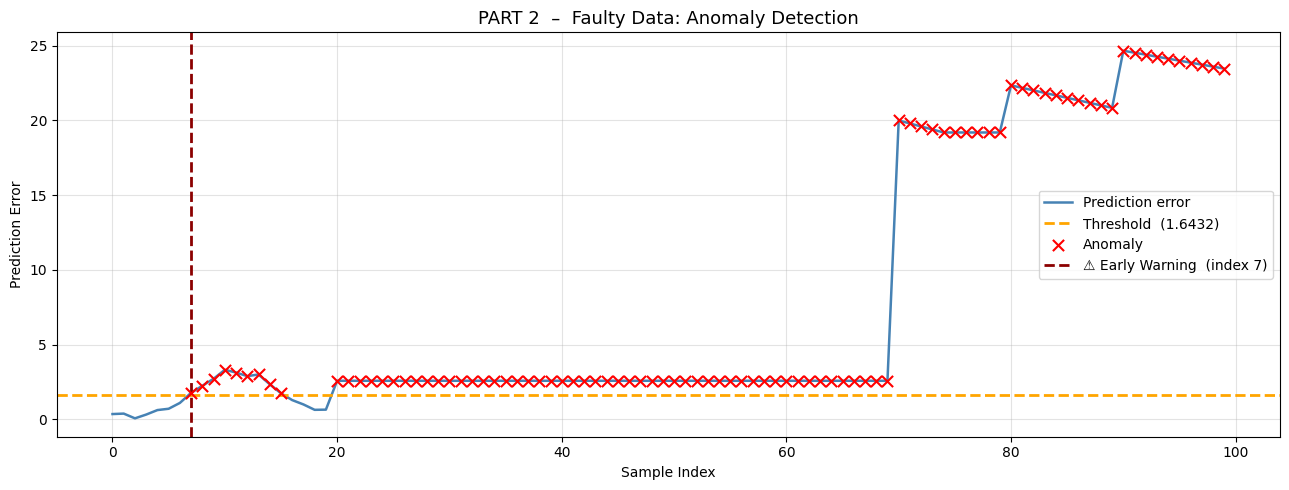


  Results saved to  distillation_results.csv


In [25]:
# ============================================================
#   DISTILLATION COLUMN  –  PREDICTIVE MAINTENANCE TOOL
# ============================================================

# ── Importing Libraries ───────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ============================================================

HEALTHY_CSV    = "distillation_healthy.csv"
FAULTY_CSV     = "distillation_faulty.csv"
OUTPUT_CSV     = "distillation_results.csv"
MODEL_FOLDER   = "models"
MODEL_NAME     = "distillation_model"

WARNING_WINDOW = 5       # consecutive anomalies needed to trigger Early Warning

INPUT_COLS  = ["Reboiler_Spec", "Condenser_Spec"]
OUTPUT_COLS = ["Condenser_Duty", "Reboiler_Duty", "T_top", "T_mid", "T_bottom"]


def load_csv(filepath):
    df = pd.read_csv(filepath)
    for col in INPUT_COLS + OUTPUT_COLS:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' is missing from  {filepath}")
    df = df.dropna()
    return df, df[INPUT_COLS].values, df[OUTPUT_COLS].values

# ── Loading healthy data ────────────────────────────────────────

df_healthy, X_healthy, y_healthy = load_csv(HEALTHY_CSV)

# ── Scaling inputs  (helps the model learn more reliably) ─────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_healthy)

# ── train–validation split ──────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_healthy, test_size=0.2, random_state=42
)

# ── Training the model ───────────────────────────
model = RandomForestRegressor(
    n_estimators      = 300,
    max_depth         = 12,
    min_samples_split = 4,
    min_samples_leaf  = 2,
    random_state      = 42,
    n_jobs            = -1
)
model.fit(X_train, y_train)

# ── Validation performance ───────────────────────────────────
y_val_pred = model.predict(X_val)
print(f"\n  Validation  R²   : {r2_score(y_val, y_val_pred):.4f}")
print(f"  Validation  MAE  : {mean_absolute_error(y_val, y_val_pred):.4f}")
print(f"  Validation  RMSE : {np.sqrt(mean_squared_error(y_val, y_val_pred)):.4f}")

# ── Calculating threshold using 3-sigma rule ───────────────────
healthy_errors = np.abs(y_val - y_val_pred).mean(axis=1)
healthy_mean   = healthy_errors.mean()
healthy_std    = healthy_errors.std()
threshold      = healthy_mean + 3 * healthy_std

print(f"\n  Healthy error mean : {healthy_mean:.6f}")
print(f"  Healthy error std  : {healthy_std:.6f}")
print(f"  ── Threshold set to : {threshold:.6f}  (mean + 3 × std) ──")

# ── Feature importance ───────────────────────────────────────
print("\n  Feature importance:")
for col, imp in zip(INPUT_COLS, model.feature_importances_):
    print(f"    {col:<20s}  {imp:.4f}")

# ── Save model & scaler ─────────────────────────────────────
os.makedirs(MODEL_FOLDER, exist_ok=True)
joblib.dump(model,  f"{MODEL_FOLDER}/{MODEL_NAME}.pkl")
joblib.dump(scaler, f"{MODEL_FOLDER}/{MODEL_NAME}_scaler.pkl")
print(f"\n  Model saved to  {MODEL_FOLDER}/")

# ── PLOT – healthy validation errors vs threshold ────────────
#    Shows that normal errors stay well below the threshold line
plt.figure(figsize=(13, 5))

plt.plot(healthy_errors, linewidth=1.8, color="steelblue", label="Healthy prediction error")
plt.axhline(threshold, linestyle="--", linewidth=2, color="orange",
            label=f"Threshold  ({threshold:.4f})")

plt.fill_between(range(len(healthy_errors)), healthy_errors, threshold,
                 where=(healthy_errors < threshold),
                 alpha=0.12, color="steelblue", label="Safe zone")

plt.title("Healthy Data: Prediction Errors vs Threshold", fontsize=13)
plt.xlabel("Validation Sample Index")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# ============================================================

# ── Load faulty data ─────────────────────────────────────────
df_faulty, X_faulty, y_faulty = load_csv(FAULTY_CSV)

X_faulty_scaled = scaler.transform(X_faulty)
y_faulty_pred   = model.predict(X_faulty_scaled)

print(f"\n  Faulty data  R²   : {r2_score(y_faulty, y_faulty_pred):.4f}")
print(f"  Faulty data  MAE  : {mean_absolute_error(y_faulty, y_faulty_pred):.4f}")
print(f"  Faulty data  RMSE : {np.sqrt(mean_squared_error(y_faulty, y_faulty_pred)):.4f}")

# ── Flagging anomalies ───────────────────────────────────────────
faulty_errors = np.abs(y_faulty - y_faulty_pred).mean(axis=1)
anomaly_flags = faulty_errors > threshold     # True = anomaly

num_anomalies = anomaly_flags.sum()
print(f"\n  Total samples checked : {len(anomaly_flags)}")
print(f"  Anomalies detected    : {num_anomalies}")
print(f"  Fault percentage      : {num_anomalies / len(anomaly_flags) * 100:.1f} %")

# ── Early Warning ─────────────────────────────────────────────
#    Raises a warning when WARNING_WINDOW consecutive samples are all anomalies
streak = 0
first_warning_index = None

for i, is_anomaly in enumerate(anomaly_flags):
    if is_anomaly:
        streak += 1
        if streak >= WARNING_WINDOW:
            first_warning_index = i - WARNING_WINDOW + 1
            break
    else:
        streak = 0

print("\n  Early Warning System:")
if first_warning_index is not None:
    print(f"  ⚠️  EARLY WARNING at sample index : {first_warning_index}")
    print(f"      ({WARNING_WINDOW} consecutive anomalies starting there)")
else:
    print("  ✅  No persistent fault pattern detected")

# ── PLOTS – faulty errors vs threshold with anomaly markers ───
plt.figure(figsize=(13, 5))

plt.plot(faulty_errors, linewidth=1.8, color="steelblue", label="Prediction error")
plt.axhline(threshold, linestyle="--", linewidth=2, color="orange",
            label=f"Threshold  ({threshold:.4f})")

anomaly_indices = np.where(anomaly_flags)[0]
plt.scatter(anomaly_indices, faulty_errors[anomaly_indices],
            marker="x", s=65, color="red", zorder=5, label="Anomaly")

if first_warning_index is not None:
    plt.axvline(first_warning_index, linestyle="--", linewidth=2, color="darkred",
                label=f"⚠ Early Warning  (index {first_warning_index})")

plt.title("PART 2  –  Faulty Data: Anomaly Detection", fontsize=13)
plt.xlabel("Sample Index")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# ── Save results CSV ─────────────────────────────────────────
df_out = df_faulty.copy()

for i, col in enumerate(OUTPUT_COLS):
    df_out[f"{col}_predicted"] = y_faulty_pred[:, i]

df_out["Prediction_Error"] = faulty_errors
df_out["Threshold"]        = threshold
df_out["Anomaly"]          = anomaly_flags.astype(int)   # 1 = fault  |  0 = normal

health_pct = 1 - (faulty_errors / faulty_errors.max())
df_out["Health_Index_%"] = np.clip(health_pct, 0, 1) * 100

df_out.to_csv(OUTPUT_CSV, index=False)
print(f"\n  Results saved to  {OUTPUT_CSV}")

